<a href="https://colab.research.google.com/github/ThienPhu2708/2001230673_PhungDuongThienPhu_THDeepLearning_Buoi04/blob/main/CNN_BT02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

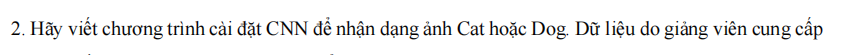



In [1]:
from google.colab import drive
drive.mount('/content/drive')

import zipfile
with zipfile.ZipFile('/content/drive/MyDrive/Dog_Cat.zip', 'r') as z:
    z.extractall('/content/dataset')

# Cấu trúc sau giải nén:
# /content/dataset/PetImages/Cat/
# /content/dataset/PetImages/Dog/

Mounted at /content/drive


In [3]:
import os
import numpy as np
import tensorflow as tf
import keras
from keras.layers import Conv2D, Dense, MaxPool2D, Flatten, Dropout
from keras.models import Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
from PIL import Image

In [4]:
def clean_corrupt_images(folder):
    removed = 0
    for fname in os.listdir(folder):
        fpath = os.path.join(folder, fname)
        try:
            img = Image.open(fpath)
            img.verify()
        except Exception:
            os.remove(fpath)
            removed += 1
    print(f"{folder}: đã xóa {removed} ảnh lỗi")

clean_corrupt_images('/content/dataset/PetImages/Cat')
clean_corrupt_images('/content/dataset/PetImages/Dog')

/content/dataset/PetImages/Cat: đã xóa 2 ảnh lỗi


/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


/content/dataset/PetImages/Dog: đã xóa 2 ảnh lỗi


In [5]:
!pip install split-folders -q

import splitfolders
splitfolders.ratio(
    '/content/dataset/PetImages',
    output='/content/dataset/split',
    seed=42,
    ratio=(0.8, 0.1, 0.1)
)

# Kết quả:
# /content/dataset/split/train/Cat, Dog
# /content/dataset/split/val/Cat,   Dog
# /content/dataset/split/test/Cat,  Dog

Copying files: 24998 files [00:16, 1548.09 files/s]


In [6]:
##Tiền xử lý dữ liệu

IMG_SIZE = (64, 64)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    '/content/dataset/split/train',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

val_generator = val_test_datagen.flow_from_directory(
    '/content/dataset/split/val',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

test_generator = val_test_datagen.flow_from_directory(
    '/content/dataset/split/test',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

print("Class indices:", train_generator.class_indices)
print("Train samples:", train_generator.samples)
print("Val samples:  ", val_generator.samples)
print("Test samples: ", test_generator.samples)

Found 19998 images belonging to 2 classes.
Found 2498 images belonging to 2 classes.
Found 2502 images belonging to 2 classes.
Class indices: {'Cat': 0, 'Dog': 1}
Train samples: 19998
Val samples:   2498
Test samples:  2502


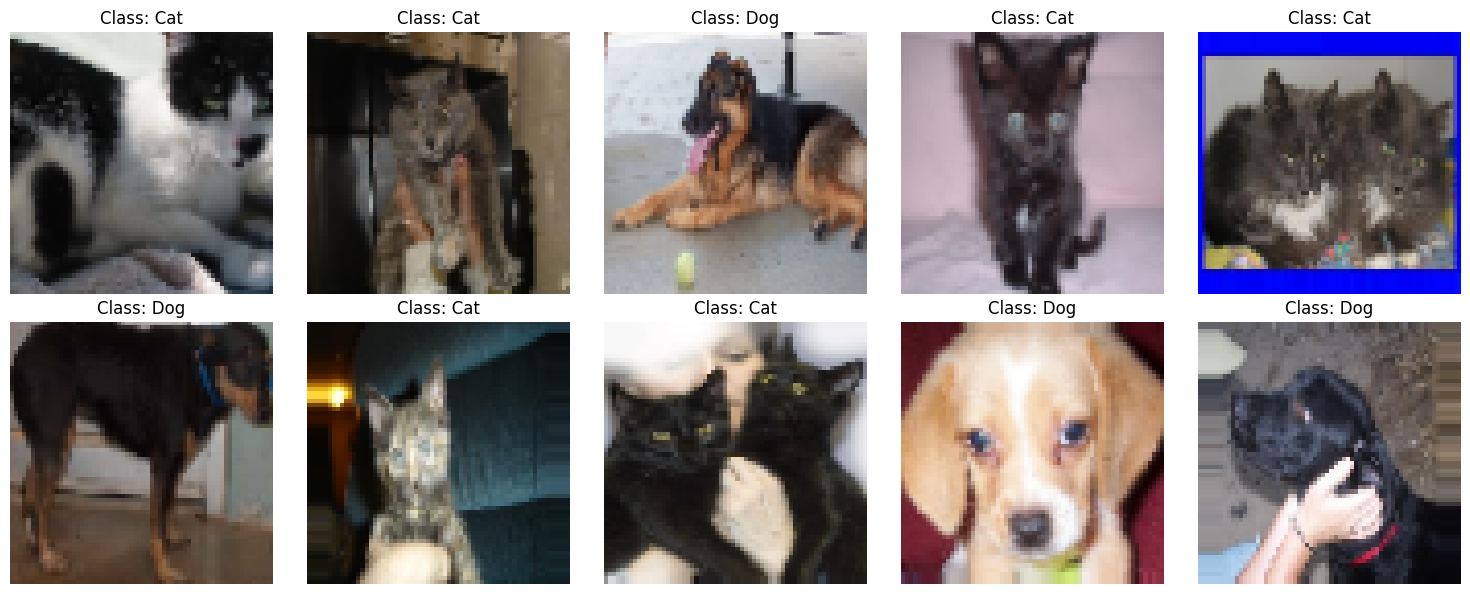

In [7]:
##Trực quan hóa 10 ảnh đầu tiên

imgs, labels = next(train_generator)
class_names = {v: k for k, v in train_generator.class_indices.items()}

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.ravel()

for i in range(10):
    axes[i].imshow(imgs[i])
    axes[i].set_title(f'Class: {class_names[int(labels[i])]}')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [8]:
##Build model
input_shape = (64, 64, 3)

model = Sequential()
model.add(keras.Input(shape=input_shape))

# Conv Block 1
model.add(Conv2D(32, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))

# Conv Block 2
model.add(Conv2D(64, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))

# Conv Block 3
model.add(Conv2D(128, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))

# Fully Connected
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))  # binary → sigmoid

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 683,329 (2.61 MB)

 Trainable params: 683,329 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
##Train model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',  # binary classification
    metrics=['accuracy']
)

model_fit = model.fit(
    train_generator,
    epochs=15,
    validation_data=val_generator,
    verbose=1
)


Epoch 1/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 220s 346ms/step - accuracy: 0.6107 - loss: 0.6485 - val_accuracy: 0.7010 - val_loss: 0.5784
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 268s 357ms/step - accuracy: 0.7180 - loss: 0.5557 - val_accuracy: 0.7698 - val_loss: 0.4809
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 206s 329ms/step - accuracy: 0.7581 - loss: 0.5019 - val_accuracy: 0.7926 - val_loss: 0.4414
Epoch 4/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 209s 334ms/step - accuracy: 0.7888 - loss: 0.4545 - val_accuracy: 0.7974 - val_loss: 0.4290
Epoch 5/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 257s 327ms/step - accuracy: 0.8067 - loss: 0.4213 - val_accuracy: 0.8335 - val_loss: 0.3806
Epoch 6/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 205s 327ms/step - accuracy: 0.8221 - loss: 0.3945 - val_accuracy: 0.8383 - val_loss: 0.3602
Epoch 7/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 209s 334ms/step - accuracy: 0.8314 - loss: 0.3773 - val_accuracy: 0.8443 - val_loss: 0.3494
Epoch 8/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 206s 330ms/step - accuracy: 0.8369 -

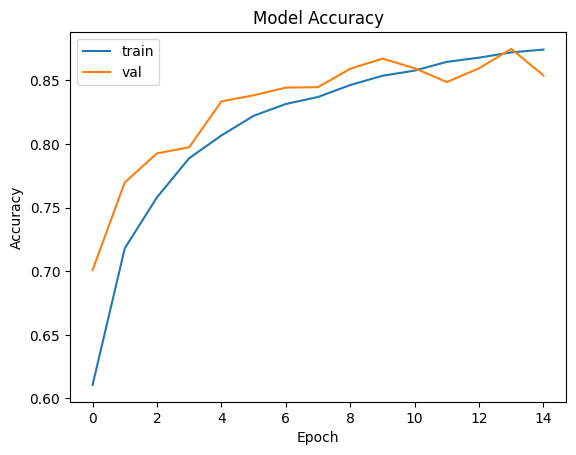

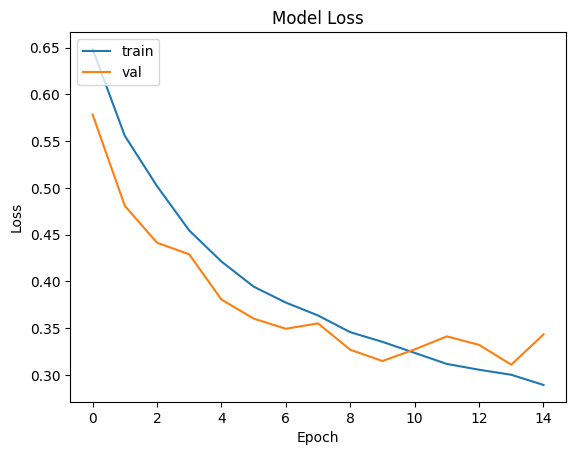

In [10]:
##vẽ biểu đồ
# Accuracy
plt.plot(model_fit.history['accuracy'])
plt.plot(model_fit.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

# Loss
plt.plot(model_fit.history['loss'])
plt.plot(model_fit.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [11]:
## Đánh giấ trên tập Test

score = model.evaluate(test_generator, verbose=2)
print('Test loss:    ', score[0])
print('Test accuracy:', score[1])

79/79 - 10s - 129ms/step - accuracy: 0.8617 - loss: 0.3219
Test loss:     0.32193008065223694
Test accuracy: 0.8617106080055237


Chọn ảnh để upload (tối đa 20 ảnh, định dạng jpg/png):


Saving 130.jpg to 130.jpg
Saving 131.jpg to 131.jpg
Saving 132.jpg to 132.jpg
Saving 133.jpg to 133.jpg
Saving 134.jpg to 134.jpg
Saving 135.jpg to 135.jpg
Saving 136.jpg to 136.jpg

Đang dự báo 7 ảnh...

[1] 130.jpg                        → Dog 🐶  (99.99%)
[2] 131.jpg                        → Dog 🐶  (100.00%)
[3] 132.jpg                        → Dog 🐶  (89.01%)
[4] 133.jpg                        → Dog 🐶  (99.91%)
[5] 134.jpg                        → Dog 🐶  (97.70%)
[6] 135.jpg                        → Cat 🐱  (62.03%)
[7] 136.jpg                        → Dog 🐶  (99.86%)


/tmp/ipykernel_3287/1590477704.py:79: UserWarning: Glyph 128054 (\N{DOG FACE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


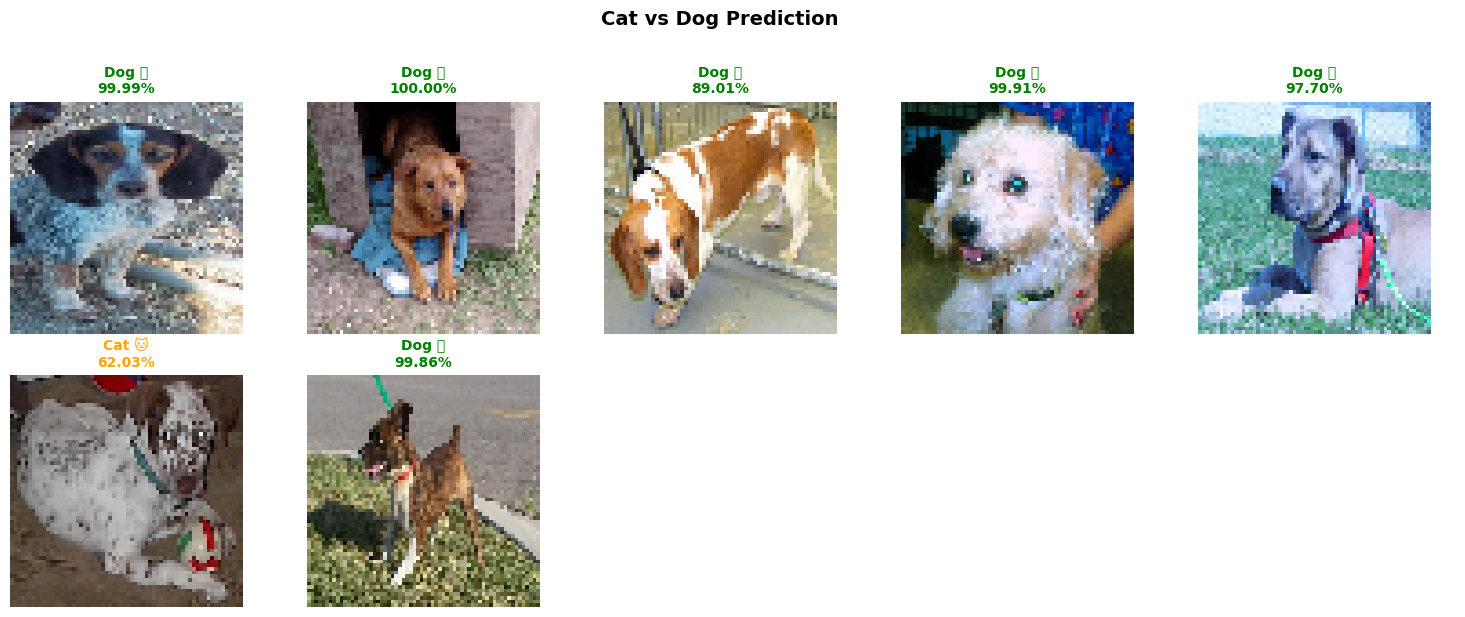

In [13]:
##Test với dữ liệu thật

from google.colab import files
from keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt
import os

def predict_uploaded_images():
    print("Chọn ảnh để upload (tối đa 20 ảnh, định dạng jpg/png):")
    uploaded = files.upload()

    if not uploaded:
        print("Không có ảnh nào được upload.")
        return

    # Lọc chỉ lấy jpg/png
    valid_files = {
        k: v for k, v in uploaded.items()
        if k.lower().endswith(('.jpg', '.jpeg', '.png'))
    }

    if not valid_files:
        print("Không tìm thấy ảnh hợp lệ (jpg/png).")
        return

    # Giới hạn 20 ảnh
    if len(valid_files) > 20:
        print(f"Chỉ xử lý 20 ảnh đầu tiên.")
        valid_files = dict(list(valid_files.items())[:20])

    n = len(valid_files)
    print(f"\nĐang dự báo {n} ảnh...\n")

    # Tính số hàng/cột cho subplot
    cols = min(n, 5)
    rows = (n + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))

    # Đảm bảo axes luôn là mảng 2D
    if n == 1:
        axes = np.array([[axes]])
    elif rows == 1:
        axes = axes.reshape(1, -1)
    elif cols == 1:
        axes = axes.reshape(-1, 1)

    for idx, (fname, _) in enumerate(valid_files.items()):
        r, c = divmod(idx, cols)
        ax = axes[r][c]

        # Load & preprocess
        img = image.load_img(fname, target_size=IMG_SIZE)
        img_array = image.img_to_array(img) / 255.0
        img_array = np.expand_dims(img_array, axis=0)

        # Predict
        pred = model.predict(img_array, verbose=0)[0][0]
        label = 'Dog 🐶' if pred > 0.5 else 'Cat 🐱'
        confidence = pred if pred > 0.5 else 1 - pred
        color = 'green' if confidence >= 0.7 else 'orange'

        ax.imshow(img)
        ax.set_title(
            f'{label}\n{confidence:.2%}',
            color=color, fontsize=10, fontweight='bold'
        )
        ax.axis('off')

        print(f"[{idx+1}] {fname:30s} → {label}  ({confidence:.2%})")

    # Ẩn các ô subplot thừa
    for idx in range(n, rows * cols):
        r, c = divmod(idx, cols)
        axes[r][c].axis('off')

    plt.suptitle('Cat vs Dog Prediction', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

    # Dọn file tạm
    for fname in valid_files:
        if os.path.exists(fname):
            os.remove(fname)

# Chạy
predict_uploaded_images()

In [15]:
model.save_weights('cat_dog_cnn.weights.h5')
model.save('cat_dog_model.keras')